In [1]:
import astropy.units as u
import astropy.constants as c
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import sys 
from astropy.io import fits
import pandas as pd
# import requests
from astropy.table import Table

sys.path.append('/Users/clairewilliams/opt/anaconda3/lib/python3.9/site-packages')
sys.path.append('../../model-timescales/src')
import pandas
from timescales.data import build_bulk_energy_grid
from timescales import TimescaleEnsemble
from timescales.analysis.model import create_dynamical_model_integral
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 15

from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(71,0.27,Ob0=0.044, Tcmb0=2.726 *u.K)

Text(0.5, 1.0, 'Figure 8 of Williams et al (2025)')

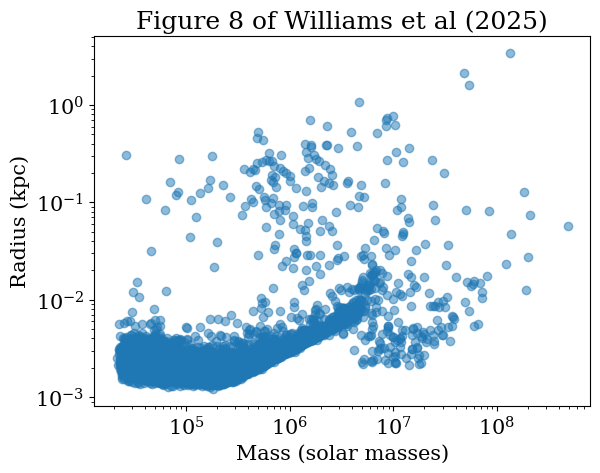

In [2]:
# Download the file
# url = 'https://raw.githubusercontent.com/astro-claire/arepo-clusters/main/starcluster_data.hdf5' 
# response = requests.get(url)

# # Save to local file
# with open('starcluster_data.hdf5', 'wb') as f:
#     f.write(response.content)

# Load the data for a specific redshift
starcluster_table = Table.read('starcluster_data.hdf5', path='redshift_12')


# Load the data for a specific redshift
starcluster_table = Table.read('starcluster_data.hdf5', path='redshift_12')

# Access specific properties
masses = starcluster_table['stellarMass (Msun)']
radii = starcluster_table['radius_hm (kpc)']

# Create the figure and axes
fig, ax = plt.subplots()

# Create the scatter plot with log axes
ax.scatter(masses, radii, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')

# Add labels and title
ax.set_xlabel('Mass (solar masses)')
ax.set_ylabel('Radius (kpc)')
ax.set_title('Figure 8 of Williams et al (2025)')


In [3]:
masses_array   = np.logspace(4, 9, 10) * u.Msun
radii_array    = np.logspace(-0.7, 2, 10) * u.pc
velocity_array = np.logspace(-0.7, 2.2, 10) * u.km/u.s

grid = build_bulk_energy_grid(masses_array, radii_array, velocity_array,
                              alpha=3/5, energy_unit=u.erg, 
                              cutoff_density=1e6*u.Msun/(u.pc**3))


# Example: access aligned arrays
M = grid['M']   # Msun
R = grid['R']   # pc
V = grid['V']   # km/s
K = grid['K']   # erg
U = grid['U']   # erg

print(len(M), len(R), len(V), len(K), len(U))  # -> 1_000_000 each (100*100*100

124 124 124 124 124


In [4]:
model = TimescaleEnsemble(grid, 
                    densityModel="power-law",
                    Nsampling = 100,
                    timescales_kwargs={'cosmology':cosmo},
                    profile_kwargs={"alpha":1.25})

Using power-law model with properties:
alpha=1.25
Using parameters for timescale evaluation
cosmology=FlatLambdaCDM(H0=71.0 km / (Mpc s), Om0=0.27, Tcmb0=2.726 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=0.044)
No imf arguments given. Defaulting to 'salpeter defaults'.


In [5]:
mass_fraction_retained = 0.1
z_final = 5
results =  create_dynamical_model_integral(model, 
                            z_final=z_final,
                            mass_fraction_retained=mass_fraction_retained,t_dist_cc=True)

will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Using nearest neighbor for interaction type.
No Metallicity given! Using 0.1 solar
2379565.9491026676 yr
2040943.9549719065 yr
18901564.197607297 yr
16211794.089240286 yr
13904789.299141493 yr
128774857.8061978 yr
110449667.3820015 yr
1022895054.7806748 yr
94732226.71427116 yr
877332893.1742934 yr
752484824.1744741 yr
6968902883.006831 yr
645403147

/Users/clairewilliams/Research/Calculations/timescale-plots/models/../../model-timescales/src/timescales/physics/halo_environment.py:135: RuntimeWarning: invalid value encountered in divide
  normalization_offset = stfunction17/stfunction


4397080457.002341 yr
40722185603.18982 yr
4437679.93659623 yr
41098184.9872317 yr
35249744.70307844 yr
30233561.458206486 yr
279998674.8447788 yr
240153715.02525237 yr
205978856.40852565 yr
1907608765.18487 yr
1636148214.0151043 yr
1403317612.6475725 yr
12996387225.859058 yr
11146948020.11839 yr
103233973229.09819 yr
9560691598.661398 yr
88543355433.83932 yr
9890433.820529234 yr
91597159.90510517 yr
8482984.52315258 yr
78562508.37318322 yr
67382741.21469192 yr
624044185.9158223 yr
57793900.77565292 yr
535240138.7994937 yr
459073271.8095466 yr
4251563546.061814 yr
3646548616.055779 yr
3127629792.0033474 yr
28965565250.278637 yr
24843646515.530884 yr
21308293722.412716 yr
197340098807.95642 yr
19258045.986635067 yr
178352370.5538826 yr
152972096.72802883 yr
1416703236.6095655 yr
131203539.96247968 yr
1215100555.5604715 yr
1042186762.8797317 yr
9651886793.108433 yr
893879312.0876682 yr
8278383716.112722 yr
7100335760.271536 yr
65757539235.9006 yr
6089928860.20315 yr
56399971704.061714 yr


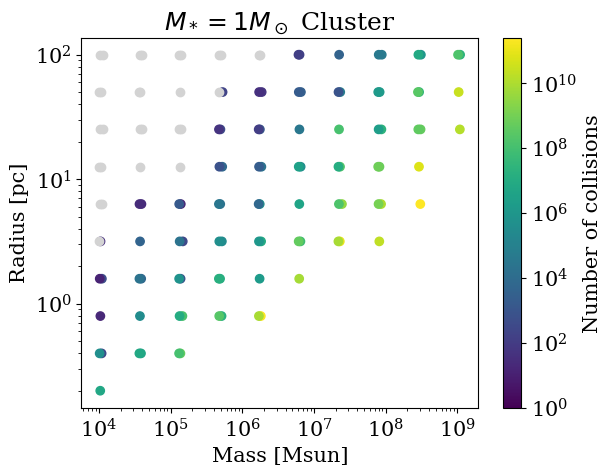

In [6]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
c = np.array(results['N_collisions'])
mflag = np.array(results['N_collisions_massloss'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=1, vmax=c_masked.max())
cmap = plt.cm.viridis

# --- Separate the two populations by shape ---
mask_star = mflag >= 1   # star markers
# mask_circle = ~mask_star # circle markers
mask_circle = c>10

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')

# Add explicit grey points for zeros
ax.scatter(x[c < 10], y[c < 10], color="lightgrey", marker='o', alpha=1, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cb.set_label("Number of collisions")

# Add legend for shapes
legend_handles = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='lightgrey',
               label='No collisions'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='gray',
               label='No mass loss'),
    plt.Line2D([], [], marker='*', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=12, label='Mass loss ≥1')
]

# ax.legend(
#     handles=legend_handles,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.4),
#     frameon=False
# )
ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
plt.title(r"$M_* = 1M_\odot$ Cluster")
plt.savefig("../plots/collisions_wholeobj_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf",bbox_inches = "tight")

plt.show()

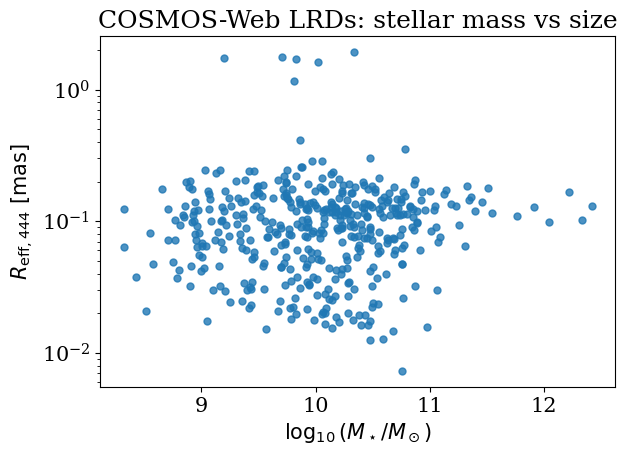

In [7]:


fn = "COSMOS-Web_LRDs.dat"

# Read ECSV (works even if extension is .dat)
tab = Table.read(fn, format="ascii.ecsv")

# Columns to use
logM = np.array(tab["logMstar_med"], dtype=float)      # log10(M*/Msun)
Re_mas = np.array(tab["Reff444_med"], dtype=float)     # mas

# Filter out sentinel values and non-finite entries
mask = np.isfinite(logM) & np.isfinite(Re_mas) & (logM > -50) & (Re_mas > 0) & (Re_mas != -99.0)

logM = np.array(tab["logMstar_med"], dtype=float)
Re_mas = np.array(tab["Reff444_med"], dtype=float)
z = np.array(tab["z_gal_med"], dtype=float)

mask = (
    np.isfinite(logM) & np.isfinite(Re_mas) & np.isfinite(z)
    & (Re_mas > 0) & (Re_mas != -99.0)
    & (z > 0)
)

logM = logM[mask]
Re_mas = Re_mas[mask] * u.mas
z = z[mask]

# Convert angular size -> physical size at each galaxy's redshift
theta_rad = Re_mas.to_value(u.rad)              # <-- plain float (dimensionless)
DA = cosmo.angular_diameter_distance(z)         # Mpc
Re_kpc = (theta_rad * DA).to(u.kpc)        

plt.figure(figsize=(6.5, 4.8))
plt.scatter(logM, Re_kpc.value, s=25, alpha=0.8)
plt.yscale("log")
plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$R_{\rm eff,444}\ [{\rm mas}]$")
plt.title("COSMOS-Web LRDs: stellar mass vs size")
plt.tight_layout()
plt.show()


In [8]:
# fits_path = "/Users/clairewilliams/Research/Calculations/JWST Data/ceers_cat_v1.0_final.fits"

# # ------------------------------------------------------------
# # Load catalog
# # ------------------------------------------------------------
# with fits.open(fits_path) as hdul:
#     data = hdul[1].data

# # ------------------------------------------------------------
# # Columns
# # ------------------------------------------------------------
# logM = data["LP_MASS_MED"]       # log10(M/Msun)
# z = data["LP_Z_MED"]

# kron = data["KRON_RADIUS"]   # dimensionless Kron scaling
# a = data["A_IMAGE"]          # semi-major axis [pix]
# b = data["B_IMAGE"]          # semi-minor axis [pix]

# # ------------------------------------------------------------
# # Quality cuts
# # ------------------------------------------------------------
# good = (
#     np.isfinite(logM) & np.isfinite(z) &
#     np.isfinite(kron) & np.isfinite(a) & np.isfinite(b) &
#     (logM > 0) & (z > 0) &
#     (kron > 0) & (a > 0) & (b > 0)
# )

# logM = logM[good]
# z = z[good]
# kron = kron[good]
# a = a[good]
# b = b[good]



# # ------------------------------------------------------------
# # Radius calculation
# # ------------------------------------------------------------
# # Optional: restrict to high-z if you want
# good_z = z > 5
# logM, z, kron, a, b = logM[good_z], z[good_z], kron[good_z], a[good_z], b[good_z]

# # ------------------------------------------------------------
# # Circularized radius in pixels
# # R_circ = kron * sqrt(a*b)
# # ------------------------------------------------------------
# r_circ_pix = kron * np.sqrt(a * b) * u.pixel

# # ------------------------------------------------------------
# # Convert pixels -> arcsec -> physical pc
# # ------------------------------------------------------------
# pixel_scale = 0.03 * u.arcsec / u.pixel  # CEERS NIRCam SW mosaic scale (typical)
# r_ang = r_circ_pix * pixel_scale         # arcsec

# DA = cosmo.angular_diameter_distance(z)  # Mpc

# # Convert using the "angles are dimensionless" equivalency
# r_phys = (r_ang.to(u.rad) * DA).to(u.pc, equivalencies=u.dimensionless_angles())

# # ------------------------------------------------------------
# # Convert stellar mass to Msun
# # ------------------------------------------------------------
# Mstar = 10**logM * u.Msun

In [9]:
cluster_datafile = "/Users/clairewilliams/Research/Calculations/JWST Data/tab_onlyJWST.txt"

df = pd.read_csv(cluster_datafile, delimiter="\t", header=0)
# Assign a custom column name to the first unnamed column
df.rename(columns={df.columns[0]: "Unnamed_Column"}, inplace=True)

# Convert to an Astropy Table if needed
table = Table.from_pandas(df)


In [10]:
goodclusters = (table["z"]>5)

print(np.unique(table['reference'][goodclusters]))

           reference            
--------------------------------
       Adamo_2024_Nature_632_513
  Claeyssens_2023_MNRAS_520_2180
Claeyssens_2024_arXiv:2410.10974
  Fujimoto_2024_arXiv:2402.18543
              Messa_2024_in_prep
          Messa_2025_AA_694A_59M
     Mowla_2024_arXiv:2402.08696
        Vanzella_2023_ApJ_945_53


/Users/clairewilliams/opt/anaconda3/envs/timescales/lib/python3.9/site-packages/astropy/cosmology/flrw/base.py:1132: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/Users/clairewilliams/opt/anaconda3/envs/timescales/lib/python3.9/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*inputs)


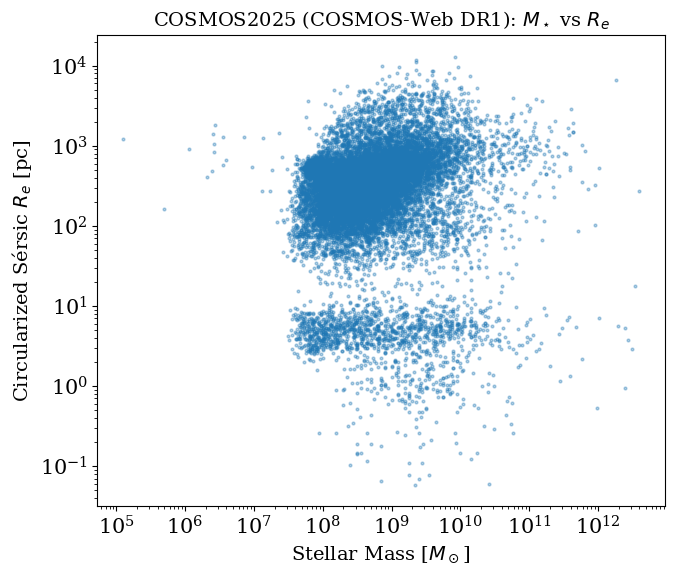

In [11]:
phot_fits = "/Users/clairewilliams/Research/Calculations/JWST Data/COSMOSWeb_mastercatalog_v1_photom_primary.fits"
leph_fits = "/Users/clairewilliams/Research/Calculations/JWST Data/COSMOSWeb_mastercatalog_v1_lephare.fits"
with fits.open(phot_fits) as hdul:
    phot = hdul[1].data

with fits.open(leph_fits) as hdul:
    lep = hdul[1].data
re_deg = phot["radius_sersic"]          # [deg]
q = phot["axratio_sersic"]              # axis ratio (b/a)
z = lep["zpdf_med"]                     # photo-z median
logMcw = lep["mass_med"]                  # log10(M/Msun)
warnflag = phot["warn_flag"]
# -------------------------------------------------------------------
# 5) Quality cuts
# -------------------------------------------------------------------
good = (
    np.isfinite(re_deg) & np.isfinite(q) &
    np.isfinite(z) & np.isfinite(logMcw) &
    (re_deg > 0) & (q > 0) &
    (z > 5) & (logMcw > 0) & 
    (warnflag ==0)
)

re_circ_ang = (re_deg * u.deg) * np.sqrt(q)                 # angle
DA = cosmo.angular_diameter_distance(z)                     # length
re_circ_pc = (re_circ_ang.to(u.rad) * DA).to(
    u.pc, equivalencies=u.dimensionless_angles()
)
Mstarcw = (10**logMcw) * u.Msun

plt.figure(figsize=(7, 6))
plt.scatter(Mstarcw.value[good], re_circ_pc.value[good],s=4, alpha=0.35)
# plt.scatter(10**(table["logM"]),table["Reff"])
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Circularized Sérsic $R_e$ [pc]", fontsize=14)
plt.xlabel(r"Stellar Mass [$M_\odot$]", fontsize=14)
plt.title("COSMOS2025 (COSMOS-Web DR1): $M_\\star$ vs $R_e$", fontsize=14)

plt.tight_layout()
plt.show()


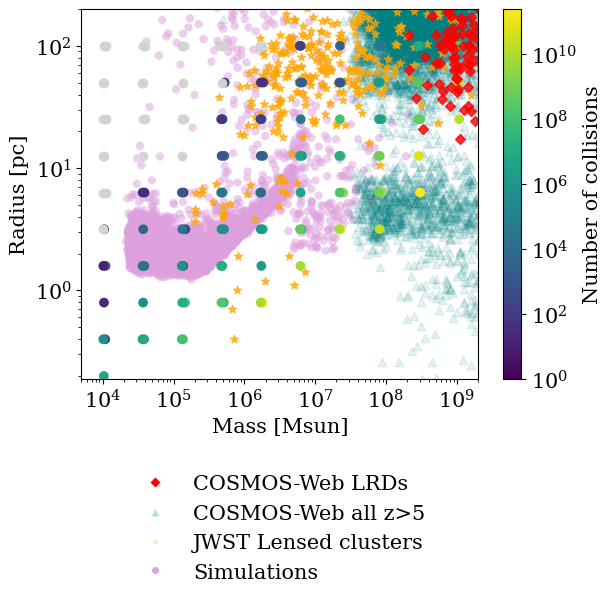

In [12]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
c = np.array(results['N_collisions'])
mflag = np.array(results['N_collisions_massloss'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=1, vmax=c_masked.max())
cmap = plt.cm.viridis

# --- Separate the two populations by shape ---
mask_star = mflag >= 1   # star markers
# mask_circle = ~mask_star # circle markers
mask_circle = c>10
masses = starcluster_table['stellarMass (Msun)']
radii = (starcluster_table['radius_hm (kpc)'] *u.kpc).to('pc')
ax.scatter(masses,radii,color = "plum",edgecolor ="none", alpha = 0.5)
# mask = Mstar.value<1e9
# plt.scatter(Mstar.value[mask],
#     r_phys.value[mask], 
#     alpha = 0.5,
#     marker = '^', 
#     color = 'teal')
plt.scatter( Mstarcw.value[good],re_circ_pc.value[good],marker = "^",alpha = 0.1,color = 'teal')

goodclusters = (table["z"]>5)
plt.scatter(10**(table["logM"][goodclusters]),table["Reff"][goodclusters], alpha = 0.7, marker = "*",color = "orange")

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')

# Add explicit grey points for zeros
ax.scatter(x[c < 10], y[c < 10], color="lightgrey", marker='o', alpha=1, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cb.set_label("Number of collisions")

# Add legend for shapes
legend_handles = [
    plt.Line2D([], [], marker='D', color='white', markerfacecolor='red',
               label='COSMOS-Web LRDs'),
    plt.Line2D([], [], marker='^', color='white', alpha = 0.3, markerfacecolor='teal',
               label='COSMOS-Web all z>5'),
    plt.Line2D([], [], marker='*', color='white', alpha = 0.3, markerfacecolor='orange',
               label='JWST Lensed clusters'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='plum',
               label='Simulations')

]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.6),
    frameon=False
)


plt.scatter(10**logM, Re_kpc.to('pc'), s=25,marker = "D", alpha=0.8, color = "red")


ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
ax.axis([.5e4,2e9,0.95*10**(-0.7),2e2])
# plt.title(r"$M_* = 1M_\odot$ Cluster")
plt.savefig("../plots/collisions_withdata_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf",bbox_inches = "tight")

plt.show()

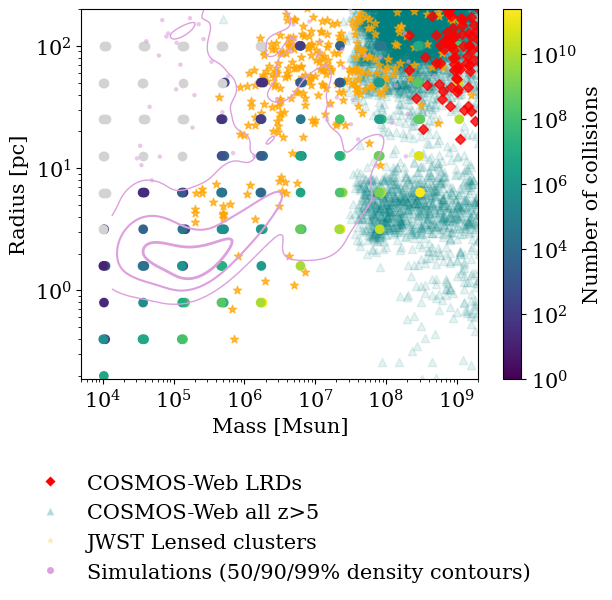

In [13]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
c = np.array(results['N_collisions'])
mflag = np.array(results['N_collisions_massloss'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=1, vmax=c_masked.max())
cmap = plt.cm.viridis

# --- Separate the two populations by shape ---
mask_star = mflag >= 1   # star markers
# mask_circle = ~mask_star # circle markers
mask_circle = c>10
from scipy.stats import gaussian_kde

# --- Take values and go to log10 space ---
masses = starcluster_table['stellarMass (Msun)'].value
radii = ((starcluster_table['radius_hm (kpc)'] * u.kpc).to('pc')).value

mask = np.isfinite(masses) & np.isfinite(radii) & (masses > 0) & (radii > 0)
xlog = np.log10(masses[mask])
ylog = np.log10(radii[mask])

# --- KDE in log–log space ---
xy = np.vstack([xlog, ylog])
kde = gaussian_kde(xy, bw_method=0.3)  # increase bw to smooth more if needed

# Grid for contours
x_grid = np.linspace(xlog.min() - 0.2, xlog.max() + 0.2, 200)
y_grid = np.linspace(ylog.min() - 0.2, ylog.max() + 0.2, 200)
Xg, Yg = np.meshgrid(x_grid, y_grid)
Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)

# --- Choose contour levels by enclosed probability, not raw density ---
Z_flat = Z.ravel()
Z_sorted = np.sort(Z_flat)[::-1]
cdf = np.cumsum(Z_sorted)
cdf /= cdf[-1]

def level_for(frac):
    # Find density threshold that encloses "frac" of the probability
    return Z_sorted[np.searchsorted(cdf, frac)]

levels = [level_for(f) for f in (0.5, 0.9, 0.99)]  # 50%, 90%, 99%
levels = [level_for(f) for f in (0.5, 0.9, 0.99)]
levels = np.array(levels)
levels.sort() 
# Back to linear mass/radius for plotting (axes are log-scaled already)
mass_grid = 10**Xg
rad_grid = 10**Yg

cs = ax.contour(
    mass_grid, rad_grid, Z,
    levels=levels,
    colors='plum',
    linewidths=[1.0, 1.5, 2.0],
    linestyles=['solid', 'solid', 'solid'],
)
Z_points = kde(xy)
thr_99 = level_for(0.99)  # same function as above
is_outlier = Z_points < thr_99

ax.scatter(
    masses[mask][is_outlier],
    radii[mask][is_outlier],
    color='plum',
    alpha=0.6,
    s=10,
    edgecolor='none',
    zorder=3,
    label='Simulation outliers'
)
# mask = Mstar.value<1e9
# plt.scatter(Mstar.value[mask],
#     r_phys.value[mask], 
#     alpha = 0.5,
#     marker = '^', 
#     color = 'teal')
plt.scatter( Mstarcw.value[good],re_circ_pc.value[good],marker = "^",alpha = 0.1,color = 'teal')

goodclusters = (table["z"]>5)
plt.scatter(10**(table["logM"][goodclusters]),table["Reff"][goodclusters], alpha = 0.7, marker = "*",color = "orange")

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')

# Add explicit grey points for zeros
ax.scatter(x[c < 10], y[c < 10], color="lightgrey", marker='o', alpha=1, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cb.set_label("Number of collisions")

# Add legend for shapes
legend_handles = [
    plt.Line2D([], [], marker='D', color='white', markerfacecolor='red',
               label='COSMOS-Web LRDs'),
    plt.Line2D([], [], marker='^', color='white', alpha = 0.3, markerfacecolor='teal',
               label='COSMOS-Web all z>5'),
    plt.Line2D([], [], marker='*', color='white', alpha = 0.3, markerfacecolor='orange',
               label='JWST Lensed clusters'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='plum',
               label='Simulations (50/90/99% density contours)')

]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.6),
    frameon=False
)


plt.scatter(10**logM, Re_kpc.to('pc'), s=25,marker = "D", alpha=0.8, color = "red")


ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
ax.axis([.5e4,2e9,0.95*10**(-0.7),2e2])
# plt.title(r"$M_* = 1M_\odot$ Cluster")
plt.savefig("../plots/collisions_withdata_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf",bbox_inches = "tight")

plt.show()

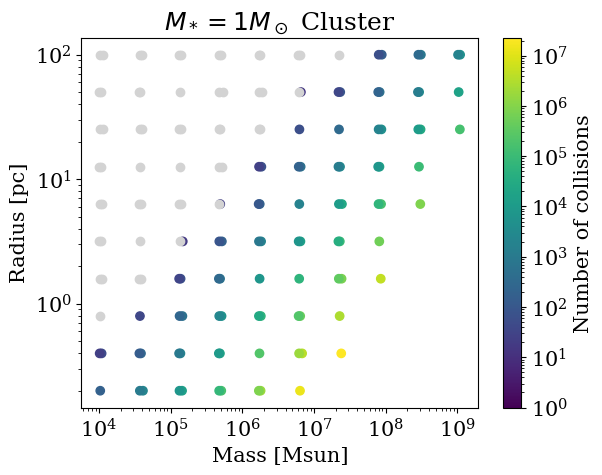

In [6]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
c = np.array(results['N_collisions_df'])
mflag = np.array(results['N_collisions_df_massloss'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=1, vmax=c_masked.max())
cmap = plt.cm.viridis

# --- Separate the two populations by shape ---
mask_star = mflag >= 1   # star markers
# mask_circle = ~mask_star # circle markers
mask_circle = c>10

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')

# Add explicit grey points for zeros
ax.scatter(x[c < 10], y[c < 10], color="lightgrey", marker='o', alpha=1, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cb.set_label("Number of collisions")

# Add legend for shapes
legend_handles = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='lightgrey',
               label='No collisions'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='gray',
               label='No mass loss'),
    plt.Line2D([], [], marker='*', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=12, label='Mass loss ≥1')
]

# ax.legend(
#     handles=legend_handles,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.4),
#     frameon=False
# )
ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
plt.title(r"$M_* = 1M_\odot$ Cluster")

plt.savefig("../plots/collisions_df_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf",bbox_inches = "tight")

plt.show()

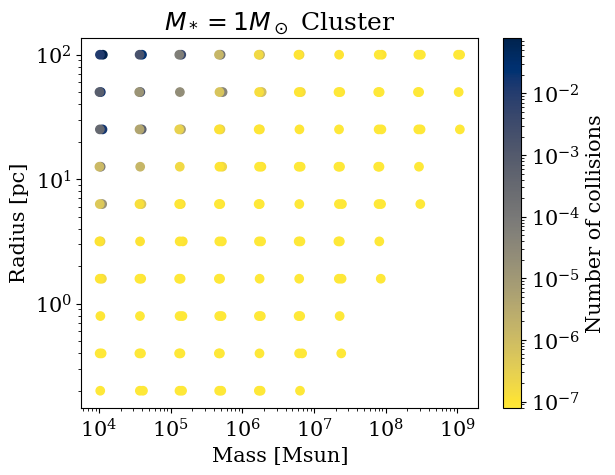

In [10]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
# c = np.array(results['N_collisions'])-np.array(results['N_collisions_df'])
c = np.array(results['fraction_collisions_df'])
mflag = np.array(results['N_collisions_df_massloss'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=c_masked.min(), vmax=c_masked.max())
cmap = plt.cm.cividis_r

# --- Separate the two populations by shape ---
mask_star = mflag >= 1   # star markers
# mask_circle = ~mask_star # circle markers
mask_circle = c<10

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap,vmin =c_masked.min(), vmax = c_masked.max(), marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')

# Add explicit grey points for zeros
ax.scatter(x[c > 10], y[c > 10], color="lightgrey", marker='o', alpha=1, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm =norm, cmap=cmap), ax=ax)
cb.set_label("Number of collisions")

# Add legend for shapes
legend_handles = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='lightgrey',
               label='No collisions'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='gray',
               label='No mass loss'),
    plt.Line2D([], [], marker='*', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=12, label='Mass loss ≥1')
]

# ax.legend(
#     handles=legend_handles,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.4),
#     frameon=False
# )
ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
plt.title(r"$M_* = 1M_\odot$ Cluster")

# plt.savefig("../plots/collisions_df_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf",bbox_inches = "tight")

plt.show()

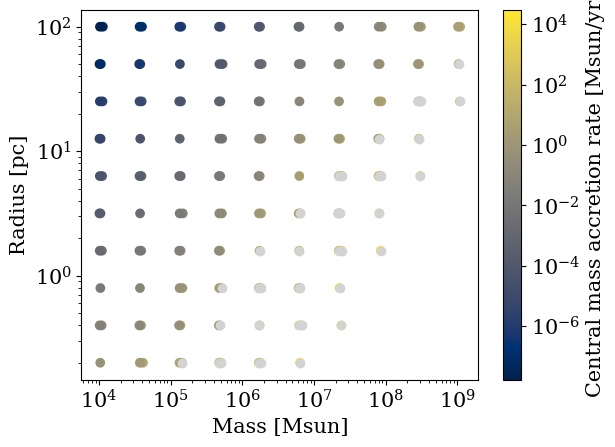

In [7]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
# c = np.array(results['N_collisions'])-np.array(results['N_collisions_df'])
c = results['mass_accretion_rate']*(u.Msun/u.yr)
c = np.array(c)
mflag = np.array(results['N_collisions_df_massloss'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=c_masked.min(), vmax=c_masked.max())
cmap = plt.cm.cividis

# --- Separate the two populations by shape ---
mask_star = mflag >= 1   # star markers
# mask_circle = ~mask_star # circle markers
mask_circle = c<1e10

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')

# Add explicit grey points for zeros
ax.scatter(x[c > 10], y[c > 10], color="lightgrey", marker='o', alpha=1, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm = norm,cmap=cmap), ax=ax)
cb.set_label(r"Central mass accretion rate [Msun/yr]")

# Add legend for shapes
legend_handles = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='lightgrey',
               label='No collisions'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='gray',
               label='No mass loss'),
    plt.Line2D([], [], marker='*', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=12, label='Mass loss ≥1')
]

# ax.legend(
#     handles=legend_handles,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.4),
#     frameon=False
# )
ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
# plt.title(r"$M_* = 1M_\odot$ Cluster")

# plt.savefig("../plots/mass_accretion_rate_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf",bbox_inches = "tight")

plt.show()

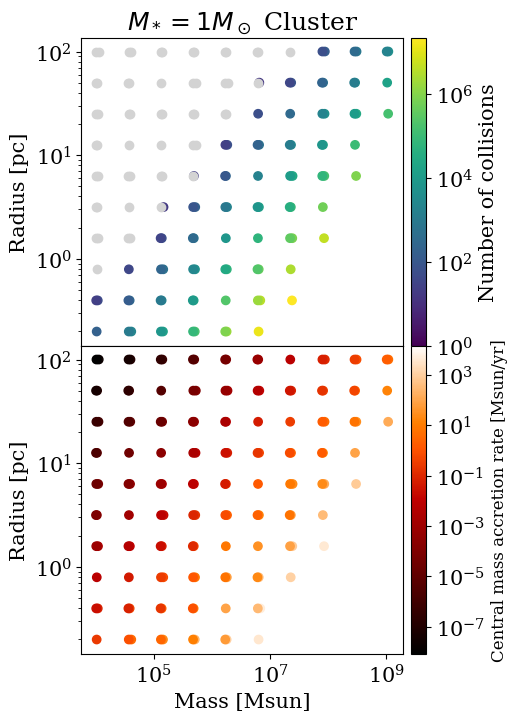

In [8]:

# --- Shared x/y for both panels ---
vratio = np.array([-results['potential'][i] / results['kinetic'][i]
                   for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value + (results['mass'][i].value * 0.01 * vratio[i])
              for i in range(len(vratio))]) * u.Msun
y = results['radius'] * u.pc
mflag = np.array(results['N_collisions_df_massloss'])

# --- Figure with two panels sharing x ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(5, 8),
    gridspec_kw={"hspace": 0.00}
)

for ax in (ax_top, ax_bot):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Radius [pc]")

# =========================
# Top panel: N_collisions_df
# =========================
c_top = np.array(results['N_collisions_df'])

c_top_masked = np.ma.masked_equal(c_top, 0)
norm_top = mcolors.LogNorm(vmin=1, vmax=c_top_masked.max())
cmap_top = plt.cm.viridis

mask_star_top = mflag >= 1
mask_circle_top = c_top > 10

ax_top.scatter(
    x[mask_circle_top], y[mask_circle_top],
    c=np.ma.masked_equal(c_top[mask_circle_top], 0),
    cmap=cmap_top, norm=norm_top, marker="o"
)
ax_top.scatter(
    x[mask_star_top], y[mask_star_top],
    c=np.ma.masked_equal(c_top[mask_star_top], 0),
    cmap=cmap_top, norm=norm_top, marker="*", s=120, edgecolor="k"
)

# Explicit grey points (your selection: c < 10)
ax_top.scatter(x[c_top < 10], y[c_top < 10],
               color="lightgrey", marker="o", alpha=1)

cb_top = fig.colorbar(cm.ScalarMappable(norm=norm_top, cmap=cmap_top),
                      ax=ax_top, pad=0.02)
cb_top.set_label("Number of collisions")

ax_top.set_title(r"$M_* = 1M_\odot$ Cluster")

# ==================================
# Bottom panel: central accretion rate
# ==================================
c_bot = results['mass_accretion_rate'] * (u.Msun / u.yr)
c_bot = np.array(c_bot)

c_bot_masked = np.ma.masked_equal(c_bot, 0)
norm_bot = mcolors.LogNorm(vmin=c_bot_masked.min(), vmax=c_bot_masked.max())
cmap_bot = plt.cm.gist_heat

mask_star_bot = mflag >= 1
mask_circle_bot = c_bot < 1e10

ax_bot.scatter(
    x[mask_circle_bot], y[mask_circle_bot],
    c=np.ma.masked_equal(c_bot[mask_circle_bot], 0),
    cmap=cmap_bot, norm=norm_bot, marker="o"
)
ax_bot.scatter(
    x[mask_star_bot], y[mask_star_bot],
    c=np.ma.masked_equal(c_bot[mask_star_bot], 0),
    cmap=cmap_bot, norm=norm_bot, marker="*", s=120, edgecolor="k"
)

# Explicit grey points (your selection: c > 10)
# ax_bot.scatter(x[c_bot > 10], y[c_bot > 10],
#                color="lightgrey", marker="o", alpha=1)

cb_bot = fig.colorbar(cm.ScalarMappable(norm=norm_bot, cmap=cmap_bot),
                      ax=ax_bot, pad=0.02)
cb_bot.set_label(r"Central mass accretion rate [Msun/yr]", fontsize = 12)

ax_bot.set_xlabel("Mass [Msun]")

# --- Save/show ---
outname = (
    "../plots/combined_collisions_accretion_"
    + str(model.Mstar) + str(model.densityModel) + str(model.alpha) + str(model.imfModel)
    + "z" + str(z_final) + ".pdf"
)
plt.savefig(outname, bbox_inches="tight")
plt.show()


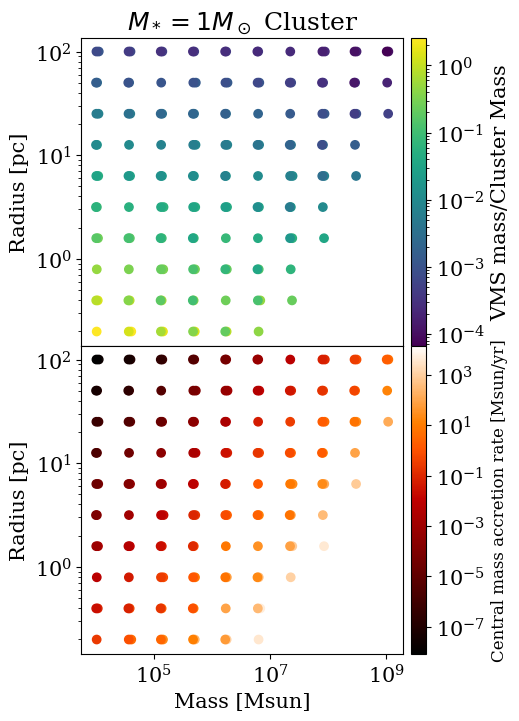

In [9]:

# --- Shared x/y for both panels ---
vratio = np.array([-results['potential'][i] / results['kinetic'][i]
                   for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value + (results['mass'][i].value * 0.01 * vratio[i])
              for i in range(len(vratio))]) * u.Msun
y = results['radius'] * u.pc
mflag = np.array(results['N_collisions_df_massloss'])

# --- Figure with two panels sharing x ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(5, 8),
    gridspec_kw={"hspace": 0.00}
)

for ax in (ax_top, ax_bot):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Radius [pc]")

# =========================
# Top panel: N_collisions_df
# =========================
c_top = np.array(results['M_VMS']*u.Msun)/np.array(results['mass']*u.Msun)

# c_top_masked = np.ma.masked_equal(c_top, 0)
c_top_masked=c_top
norm_top = mcolors.LogNorm(vmin=c_top.min(), vmax=c_top_masked.max())
cmap_top = plt.cm.viridis

mask_star_top = mflag >= 1
mask_circle_top = c_top > 1e-9

ax_top.scatter(
    x[mask_circle_top], y[mask_circle_top],
    c=np.ma.masked_equal(c_top[mask_circle_top], 0),
    cmap=cmap_top, norm=norm_top, marker="o"
)
ax_top.scatter(
    x[mask_star_top], y[mask_star_top],
    c=np.ma.masked_equal(c_top[mask_star_top], 0),
    cmap=cmap_top, norm=norm_top, marker="*", s=120, edgecolor="k"
)

# Explicit grey points (your selection: c < 10)
# ax_top.scatter(x[c_top < 10], y[c_top < 10],
#                color="lightgrey", marker="o", alpha=1)

cb_top = fig.colorbar(cm.ScalarMappable(norm=norm_top, cmap=cmap_top),
                      ax=ax_top, pad=0.02)
cb_top.set_label("VMS mass/Cluster Mass")

ax_top.set_title(r"$M_* = 1M_\odot$ Cluster")

# ==================================
# Bottom panel: central accretion rate
# ==================================
c_bot = results['mass_accretion_rate'] * (u.Msun / u.yr)
c_bot = np.array(c_bot)

c_bot_masked = np.ma.masked_equal(c_bot, 0)
norm_bot = mcolors.LogNorm(vmin=c_bot_masked.min(), vmax=c_bot_masked.max())
cmap_bot = plt.cm.gist_heat

mask_star_bot = mflag >= 1
mask_circle_bot = c_bot < 1e10

ax_bot.scatter(
    x[mask_circle_bot], y[mask_circle_bot],
    c=np.ma.masked_equal(c_bot[mask_circle_bot], 0),
    cmap=cmap_bot, norm=norm_bot, marker="o"
)
ax_bot.scatter(
    x[mask_star_bot], y[mask_star_bot],
    c=np.ma.masked_equal(c_bot[mask_star_bot], 0),
    cmap=cmap_bot, norm=norm_bot, marker="*", s=120, edgecolor="k"
)

# Explicit grey points (your selection: c > 10)
# ax_bot.scatter(x[c_bot > 10], y[c_bot > 10],
#                color="lightgrey", marker="o", alpha=1)

cb_bot = fig.colorbar(cm.ScalarMappable(norm=norm_bot, cmap=cmap_bot),
                      ax=ax_bot, pad=0.02)
cb_bot.set_label(r"Central mass accretion rate [Msun/yr]", fontsize = 12)

ax_bot.set_xlabel("Mass [Msun]")

# --- Save/show ---
# outname = (
#     "../plots/combined_collisions_accretion_"
#     + str(model.Mstar) + str(model.densityModel) + str(model.alpha) + str(model.imfModel)
#     + "z" + str(z_final) + ".pdf"
# )
plt.savefig(outname, bbox_inches="tight")
plt.show()


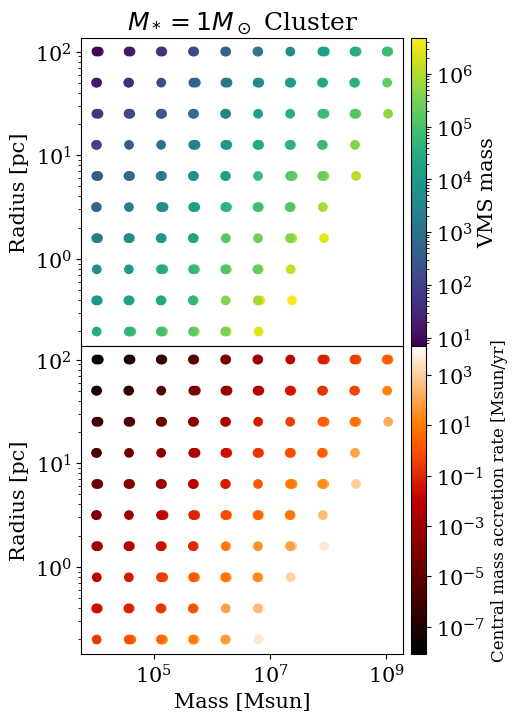

In [10]:

# --- Shared x/y for both panels ---
vratio = np.array([-results['potential'][i] / results['kinetic'][i]
                   for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value + (results['mass'][i].value * 0.01 * vratio[i])
              for i in range(len(vratio))]) * u.Msun
y = results['radius'] * u.pc
mflag = np.array(results['N_collisions_df_massloss'])

# --- Figure with two panels sharing x ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(5, 8),
    gridspec_kw={"hspace": 0.00}
)

for ax in (ax_top, ax_bot):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Radius [pc]")

# =========================
# Top panel: N_collisions_df
# =========================
c_top = np.array(results['M_VMS']*u.Msun)
# c_top_masked = np.ma.masked_equal(c_top, 0)
c_top_masked=c_top
norm_top = mcolors.LogNorm(vmin=c_top.min(), vmax=c_top_masked.max())
cmap_top = plt.cm.viridis

mask_star_top = mflag >= 1
mask_circle_top = c_top > 1e-9

ax_top.scatter(
    x[mask_circle_top], y[mask_circle_top],
    c=np.ma.masked_equal(c_top[mask_circle_top], 0),
    cmap=cmap_top, norm=norm_top, marker="o"
)
ax_top.scatter(
    x[mask_star_top], y[mask_star_top],
    c=np.ma.masked_equal(c_top[mask_star_top], 0),
    cmap=cmap_top, norm=norm_top, marker="*", s=120, edgecolor="k"
)

# Explicit grey points (your selection: c < 10)
# ax_top.scatter(x[c_top < 10], y[c_top < 10],
#                color="lightgrey", marker="o", alpha=1)

cb_top = fig.colorbar(cm.ScalarMappable(norm=norm_top, cmap=cmap_top),
                      ax=ax_top, pad=0.02)
cb_top.set_label("VMS mass")

ax_top.set_title(r"$M_* = 1M_\odot$ Cluster")

# ==================================
# Bottom panel: central accretion rate
# ==================================
c_bot = results['mass_accretion_rate'] * (u.Msun / u.yr)
c_bot = np.array(c_bot)

c_bot_masked = np.ma.masked_equal(c_bot, 0)
norm_bot = mcolors.LogNorm(vmin=c_bot_masked.min(), vmax=c_bot_masked.max())
cmap_bot = plt.cm.gist_heat

mask_star_bot = mflag >= 1
mask_circle_bot = c_bot < 1e10

ax_bot.scatter(
    x[mask_circle_bot], y[mask_circle_bot],
    c=np.ma.masked_equal(c_bot[mask_circle_bot], 0),
    cmap=cmap_bot, norm=norm_bot, marker="o"
)
ax_bot.scatter(
    x[mask_star_bot], y[mask_star_bot],
    c=np.ma.masked_equal(c_bot[mask_star_bot], 0),
    cmap=cmap_bot, norm=norm_bot, marker="*", s=120, edgecolor="k"
)

# Explicit grey points (your selection: c > 10)
# ax_bot.scatter(x[c_bot > 10], y[c_bot > 10],
#                color="lightgrey", marker="o", alpha=1)

cb_bot = fig.colorbar(cm.ScalarMappable(norm=norm_bot, cmap=cmap_bot),
                      ax=ax_bot, pad=0.02)
cb_bot.set_label(r"Central mass accretion rate [Msun/yr]", fontsize = 12)

ax_bot.set_xlabel("Mass [Msun]")

# --- Save/show ---
# outname = (
#     "../plots/combined_collisions_accretion_"
#     + str(model.Mstar) + str(model.densityModel) + str(model.alpha) + str(model.imfModel)
#     + "z" + str(z_final) + ".pdf"
# )
plt.savefig(outname, bbox_inches="tight")
plt.show()


[9.34136981e+08 9.34136981e+08 9.33155666e+08 9.31202301e+08
 9.31202301e+08 9.27323107e+08 9.19655181e+08 9.19655181e+08
 9.04637144e+08 9.04637144e+08 8.75750941e+08 8.75750941e+08
 8.22101091e+08 8.22101091e+08 7.28800925e+08 7.28800925e+08
 5.84508085e+08 5.84508085e+08]


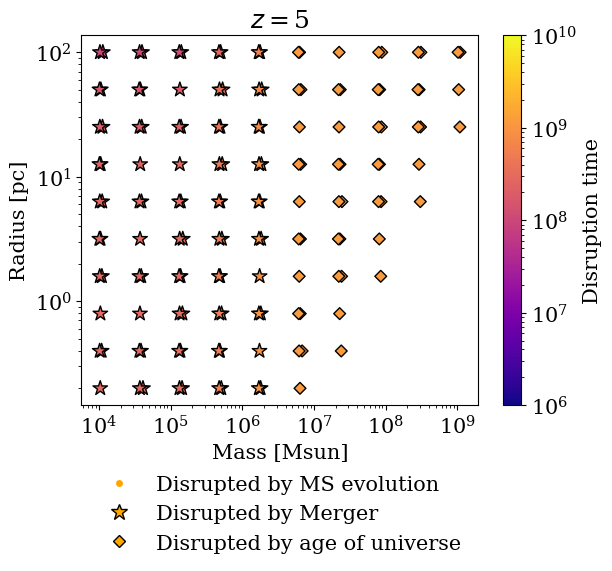

In [98]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
c = np.array(results['minimum_disruption_time']*u.yr)
mflag = np.array(results['which_disruption_time'])  # new flag array


print(c[np.where((x.value>1e6)&(x.value<5e6))[0]])
fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=1e6, vmax=1e10)
cmap = plt.cm.plasma

# --- Separate the two populations by shape ---
mask_star = mflag == 0   # star markers
mask_circle = mflag == 1 # circle markers
mask_square= mflag == 2 # circle markers

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')
# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_square], y[mask_square], 
                 c=np.ma.masked_equal(c[mask_square], 0), 
                 cmap=cmap, norm=norm, marker='D',edgecolor='k')

# # Add explicit grey points for zeros
# ax.scatter(x[c == 0], y[c == 0], color="lightgrey", marker='o', alpha=0.7, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cb.set_label("Disruption time")

# Add legend for shapes
legend_handles = [
    # plt.Line2D([], [], marker='o', color='w', markerfacecolor='lightgrey',
    #            label='No collisions'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='orange',
               label='Disrupted by MS evolution'),
    plt.Line2D([], [], marker='*', color='w', markerfacecolor='orange',
               markeredgecolor='k', markersize=12, label='Disrupted by Merger'),
    plt.Line2D([], [], marker='D', color='w', markerfacecolor='orange',
               markeredgecolor='k', label='Disrupted by age of universe')
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.45),
    frameon=False
)
ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
plt.title(r"$z= $"+str(z_final))
plt.savefig("../plots/disruption_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf")
plt.show()

In [40]:
model = TimescaleEnsemble(grid, 
                    densityModel="power-law",
                    Nsampling = 100,
                    timescales_kwargs={'cosmology':cosmo},
                    profile_kwargs={"alpha":1.25})

mass_fraction_retained = 0.1
z_final = 8
results =  create_dynamical_model_integral(model, 
                            z_final=z_final,
                            mass_fraction_retained=mass_fraction_retained)

Using power-law model with properties:
alpha=1.25
Using parameters for timescale evaluation
cosmology=FlatLambdaCDM(H0=71.0 km / (Mpc s), Om0=0.27, Tcmb0=2.726 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=0.044)
No imf arguments given. Defaulting to 'salpeter'.
will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Using nearest neighbor for interaction type.


/Users/clairewilliams/Research/Calculations/timescale-plots/models/../../model-timescales/src/timescales/physics/halo_environment.py:135: RuntimeWarning: invalid value encountered in divide
  normalization_offset = stfunction17/stfunction


collisions occur in 131 systems
mass loss occurs in 0 systems
0


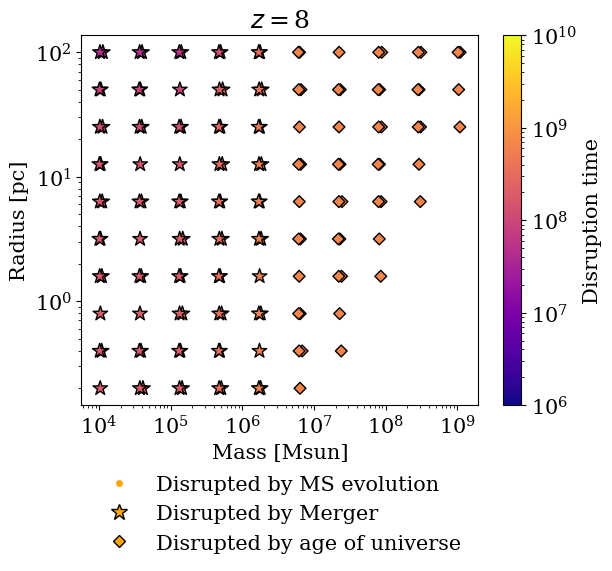

In [41]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
c = np.array(results['minimum_disruption_time']*u.yr)
mflag = np.array(results['which_disruption_time'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=1e6, vmax=1e10)
cmap = plt.cm.plasma

# --- Separate the two populations by shape ---
mask_star = mflag == 0   # star markers
mask_circle = mflag == 1 # circle markers
mask_square= mflag == 2 # circle markers

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')
# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_square], y[mask_square], 
                 c=np.ma.masked_equal(c[mask_square], 0), 
                 cmap=cmap, norm=norm, marker='D',edgecolor='k')

# # Add explicit grey points for zeros
# ax.scatter(x[c == 0], y[c == 0], color="lightgrey", marker='o', alpha=0.7, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cb.set_label("Disruption time")

# Add legend for shapes
legend_handles = [
    # plt.Line2D([], [], marker='o', color='w', markerfacecolor='lightgrey',
    #            label='No collisions'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='orange',
               label='Disrupted by MS evolution'),
    plt.Line2D([], [], marker='*', color='w', markerfacecolor='orange',
               markeredgecolor='k', markersize=12, label='Disrupted by Merger'),
    plt.Line2D([], [], marker='D', color='w', markerfacecolor='orange',
               markeredgecolor='k', label='Disrupted by age of universe')
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.45),
    frameon=False
)
ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
plt.title(r"$z= $"+str(z_final))
plt.savefig("../plots/disruption_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf")
plt.show()

In [42]:
model = TimescaleEnsemble(grid, 
                    densityModel="power-law",
                    Nsampling = 100,
                    timescales_kwargs={'cosmology':cosmo},
                    profile_kwargs={"alpha":1.25})

mass_fraction_retained = 0.1
z_final = 5
results =  create_dynamical_model_integral(model, 
                            z_final=z_final,
                            mass_fraction_retained=mass_fraction_retained)

Using power-law model with properties:
alpha=1.25
Using parameters for timescale evaluation
cosmology=FlatLambdaCDM(H0=71.0 km / (Mpc s), Om0=0.27, Tcmb0=2.726 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=0.044)
No imf arguments given. Defaulting to 'salpeter'.
will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Using nearest neighbor for interaction type.


/Users/clairewilliams/Research/Calculations/timescale-plots/models/../../model-timescales/src/timescales/physics/halo_environment.py:135: RuntimeWarning: invalid value encountered in divide
  normalization_offset = stfunction17/stfunction


collisions occur in 135 systems
mass loss occurs in 0 systems
0


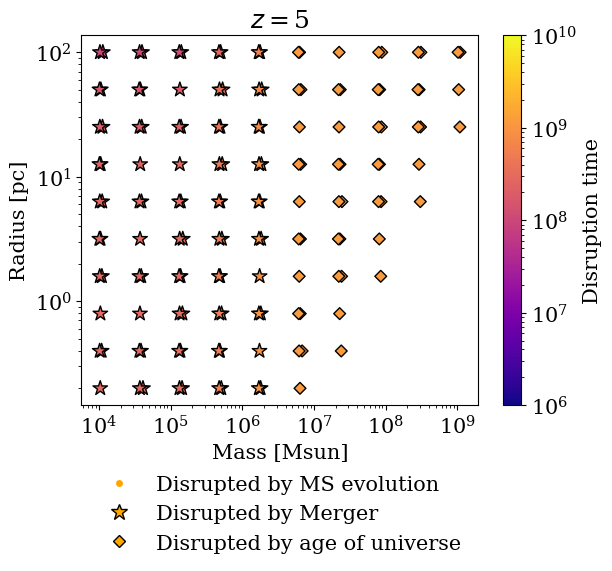

In [43]:
vratio = np.array([-results['potential'][i]/results['kinetic'][i] for i in range(len(results['potential']))])
x = np.array([results['mass'][i].value+(results['mass'][i].value *0.01 * vratio[i]) for i in range(len(vratio))]) * u.Msun
y = results['radius'] *u.pc
c = np.array(results['minimum_disruption_time']*u.yr)
mflag = np.array(results['which_disruption_time'])  # new flag array

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')

# Mask zeros for log-scaling
c_masked = np.ma.masked_equal(c, 0)
norm = mcolors.LogNorm(vmin=1e6, vmax=1e10)
cmap = plt.cm.plasma

# --- Separate the two populations by shape ---
mask_star = mflag == 0   # star markers
mask_circle = mflag == 1 # circle markers
mask_square= mflag == 2 # circle markers

# Plot circles (no mass loss)
sc1 = ax.scatter(x[mask_circle], y[mask_circle], 
                 c=np.ma.masked_equal(c[mask_circle], 0), 
                 cmap=cmap, norm=norm, marker='o')

# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_star], y[mask_star], 
                 c=np.ma.masked_equal(c[mask_star], 0), 
                 cmap=cmap, norm=norm, marker='*', s=120, edgecolor='k')
# Plot stars (mass loss ≥1)
sc2 = ax.scatter(x[mask_square], y[mask_square], 
                 c=np.ma.masked_equal(c[mask_square], 0), 
                 cmap=cmap, norm=norm, marker='D',edgecolor='k')

# # Add explicit grey points for zeros
# ax.scatter(x[c == 0], y[c == 0], color="lightgrey", marker='o', alpha=0.7, label="0 collisions")

# --- Colorbar ---
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cb.set_label("Disruption time")

# Add legend for shapes
legend_handles = [
    # plt.Line2D([], [], marker='o', color='w', markerfacecolor='lightgrey',
    #            label='No collisions'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='orange',
               label='Disrupted by MS evolution'),
    plt.Line2D([], [], marker='*', color='w', markerfacecolor='orange',
               markeredgecolor='k', markersize=12, label='Disrupted by Merger'),
    plt.Line2D([], [], marker='D', color='w', markerfacecolor='orange',
               markeredgecolor='k', label='Disrupted by age of universe')
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.45),
    frameon=False
)
ax.set_xlabel("Mass [Msun]")
ax.set_ylabel("Radius [pc]")
plt.title(r"$z= $"+str(z_final))
plt.savefig("../plots/disruption_"+str(model.Mstar)+str(model.densityModel)+str(model.alpha)+str(model.imfModel)+"z"+str(z_final)+".pdf")
plt.show()